## Import the libraries


In [2]:
import torch 
import torch.nn as nn  # this is the main pytorch library 
import torch.nn.functional as F  # this contains the activation functions and other function that are used in the forward pass of the network
import torch.optim as optim  # this is the library that contains the optimizers that are used to update the weights of the network 

# the following libraries are from the torch_geometric library which is a library for graph neural networks in pytorch
import torch_geometric  # this is the main library for graph neural networks in pytorch
from torch_geometric.datasets import TUDataset  # this is the library that contains the TUDataset class that is used to load the datasets
from torch_geometric.data import DataLoader  # this is the library that contains the DataLoader class that is used to load the data in batches
import torch_geometric.nn as pyg_nn  # this is the library that contains the graph neural network layers that are used in the network
import torch_geometric.transforms as T  # this contains preprocessing transforms such as feature normalization
import torch_geometric.utils as pyg_utils  # this is the library that contains the utility functions that are used in the network


from sklearn.manifold import TSNE  # this is the library that contains the TSNE class that is used to visualize the embeddings of the nodes in the graph
import matplotlib.pyplot as plt  # this is the library that contains the pyplot module that is used to visualize the embeddings of the nodes in the graph
import numpy as np  # this is the library that contains the numpy module that is used to manipulate the data and the embeddings of the nodes in the graph
import networkx as nx  # this is the library that contains the networkx module that is used to visualize the graphs and the embeddings of the nodes in the graph


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # this is the device that is used to run the network on the GPU if it is available, otherwise it runs on the CPU
# cuda is 
print("Using device:", device)

Using device: cpu


## Step 2 Load the MUTAG dataset
- Uses TUDataset which contains many small graphs.
- Shuffles and splits into 80% train and 20% test.
- NormalizeFeatures scales node features.
- loader_train and loader_test yield batches of graphs.

In [3]:
dataset = TUDataset(root='data/TUDataset', name='MUTAG', use_node_attr=False, transform=T.NormalizeFeatures()) 
# use_node_attr=False means that we don't want to use the node attributes in the dataset. node attributes are the features of the nodes in the graph. 
# if use_node_attr=True, then we would use the node attributes as the features of the nodes in the graph. if use_node_attr=False, then we would use the degree of the nodes as the features of the nodes in the graph. T.NormalizeFeatures() is a transform that normalizes the features of the nodes in the graph. 
# this is important because it helps to improve the performance of the network by making sure that all the features are on the same scale.    
dataset = dataset.shuffle()
n = len(dataset)
n_train = int(0.8 * n)
train_dataset = dataset[:n_train]
test_dataset = dataset[n_train:]

print(f"Loaded MUTAG. Total graphs: {len(dataset)} | Train: {len(train_dataset)} | Test: {len(test_dataset)}")

loader_train = DataLoader(train_dataset, batch_size=64, shuffle=True) # shuffle=True because we want to randomize the order of the graphs in the training set
loader_test = DataLoader(test_dataset, batch_size=64, shuffle=False)  # shuffle=False because we want to keep the same order of the graphs in the test set

Processing...


Loaded MUTAG. Total graphs: 188 | Train: 150 | Test: 38


Done!
C:\Users\My Device\AppData\Local\Temp\ipykernel_17396\3135449960.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader_train = DataLoader(train_dataset, batch_size=64, shuffle=True) # shuffle=True because we want to randomize the order of the graphs in the training set
C:\Users\My Device\AppData\Local\Temp\ipykernel_17396\3135449960.py:14: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader_test = DataLoader(test_dataset, batch_size=64, shuffle=False)  # shuffle=False because we want to keep the same order of the graphs in the test set


## Step 3: Define the GNN model
- GINConv is a useful graph aggregator for graph classification.
- num_layers controls message passing depth.
- global_mean_pool pools node embeddings to graph embeddings.
- post_mp is an MLP that converts pooled embedding to class logits.
- loss() returns NLL loss expecting F.log_softmax outputs.

In [4]:
class GNNStack(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=3, dropout=0.25):
        # input_dim is the dimension of the input features of the nodes in the graph. 
        # hidden_dim is the dimension of the hidden layers in the network. 
        # output_dim is the dimension of the output layer in the network. 
        # num_layers is the number of layers in the network. 
        # dropout is the dropout rate that is used to prevent overfitting in the network.

        # super() is a function that is used to call the constructor of the parent class.
        super(GNNStack, self).__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.convs = nn.ModuleList()

        # the following is the first layer of the network that is used to map the input features of the nodes in the graph to the hidden layers in the network.
        self.convs.append(pyg_nn.GINConv(nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)
        )))

        # the following loop is used to create the hidden layers in the network.
        for _ in range(1, num_layers):
            self.convs.append(pyg_nn.GINConv(nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)
            )))
        self.lns = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers - 1)])

        # the following is the post_mp layer that is used to map the output of the graph neural network to the output layer of the network.
        self.post_mp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    # the following function is used to forward propagate the input features of the nodes in the graph through the network.
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # x: the input features of the nodes in the graph. 
        # if use_node_attr=False, then x is None and we will use the degree of the nodes as the features of the nodes in the graph. 
        # if use_node_attr=True, then x is not None and we will use the input features of the nodes in the graph as the features of the nodes in the graph.
        # edge_index: is  
        # batch: is the 
        if x is None:
            x = torch.ones((data.num_nodes, 1), device=edge_index.device)

        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i != self.num_layers - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
                x = self.lns[i](x)

        emb = x  
        g_emb = pyg_nn.global_mean_pool(emb, batch)
        out = self.post_mp(g_emb)
        return emb, F.log_softmax(out, dim=1)

    def loss(self, pred_logprob, label):
        return F.nll_loss(pred_logprob, label)

## Activation functions and their use cases

Common activation functions:
- tanh
- softmax
- sigmoid
- relu
- elu
- prelu
- ...

| Function | Gradient property | Risk factor | Where to use |
| --- | --- | --- | --- |
| Sigmoid | Vanishing: max gradient is only 0.25. | High risk in deep hidden layers. | Output layer for binary classification (0 or 1). |
| Tanh | Vanishing: better than sigmoid, but still saturates. | Medium risk in deep networks. | RNNs and hidden layers with zero-centered data. |
| ReLU | Constant: gradient is 1 for x > 0. | Dying ReLU: gradient is 0 for x < 0. | Standard choice for hidden layers in CNNs and MLPs. |
| Leaky ReLU | Non-zero gradient for x < 0 (e.g. 0.01). | Low risk. Prevents dead neurons. | GNNs, GANs, and very deep architectures. |
| Softmax | Differential: compares relative scale of inputs. | Can be sensitive to outliers before normalization. | Final layer for multi-class classification. |


## Step 4: Instantiate model and optimizer
- input_dim uses dataset node features.
- Move model to device.
- Adam optimizer with small weight decay for regularization.

In [5]:
input_dim = max(1, dataset.num_node_features)
num_classes = dataset.num_classes

model = GNNStack(input_dim=input_dim, hidden_dim=64, output_dim=num_classes, num_layers=3, dropout=0.25).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

print(model)

GNNStack(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=7, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
    (1-2): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (lns): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (post_mp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


## Step 5: Training and evaluation helpers
- train_graph_epoch trains for one epoch across batches.
- Multiply loss by batch.num_graphs to accumulate correctly.
- eval_graph computes accuracy over test batches.
- Functions expect batches moved to device.

In [6]:
def train_graph_epoch(loader):
    model.train()
    total_loss = 0.0
    total_graphs = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        emb, pred = model(batch) 
        loss = model.loss(pred, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs
    return total_loss / total_graphs

@torch.no_grad()
def eval_graph(loader):
    model.eval()
    correct = 0
    total = 0
    for batch in loader:
        batch = batch.to(device)
        emb, pred = model(batch)
        pred_label = pred.argmax(dim=1)
        correct += (pred_label == batch.y).sum().item()
        total += batch.num_graphs
    return correct / total

## Step 6: Run training loop & log metrics
- Train for num_epochs, store loss and test accuracy lists.

In [7]:
num_epochs = 100
train_losses = []
test_scores = []

for epoch in range(1, num_epochs + 1):
    loss = train_graph_epoch(loader_train)
    acc = eval_graph(loader_test)
    train_losses.append(loss)
    test_scores.append(acc)
    if epoch % 10 == 0 or epoch == 1:
        print(f"[Graph] Epoch {epoch:03d} | Loss: {loss:.4f} | Test Acc: {acc:.4f}")

[Graph] Epoch 001 | Loss: 0.7343 | Test Acc: 0.6842
[Graph] Epoch 010 | Loss: 0.6443 | Test Acc: 0.6842
[Graph] Epoch 020 | Loss: 0.5193 | Test Acc: 0.6842
[Graph] Epoch 030 | Loss: 0.5145 | Test Acc: 0.6316
[Graph] Epoch 040 | Loss: 0.4585 | Test Acc: 0.6316
[Graph] Epoch 050 | Loss: 0.5229 | Test Acc: 0.6053
[Graph] Epoch 060 | Loss: 0.4993 | Test Acc: 0.6579
[Graph] Epoch 070 | Loss: 0.4716 | Test Acc: 0.6316
[Graph] Epoch 080 | Loss: 0.4826 | Test Acc: 0.6842
[Graph] Epoch 090 | Loss: 0.4826 | Test Acc: 0.6842
[Graph] Epoch 100 | Loss: 0.4726 | Test Acc: 0.7368


## Step 7: Plot training loss and test accuracy
- Use these to check convergence and overfitting.

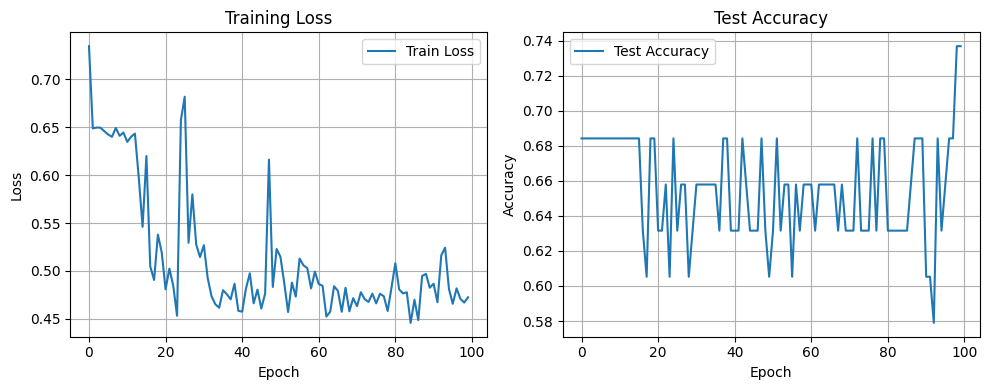

In [8]:
plt.figure(figsize=(10,4))  # The figure is the canvas on which we will plot the training loss and the test accuracy. 
# figsize is the size of the figure in inches. 
# (10,4) means that the width of the figure is 10 inches and the height of the figure is 4 inches.
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss'); plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(test_scores, label='Test Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Test Accuracy'); plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

## Step 8: Get graph embeddings and t-SNE visualization
- Run model over all graphs, pool node embeddings to get graph-level embeddings.
- Apply t-SNE to reduce to 2D and scatter-plot colored by class.
- Clusters indicate separability of learned graph representations.

C:\Users\My Device\AppData\Local\Temp\ipykernel_17396\3063255066.py:6: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(dataset, batch_size=64, shuffle=False)


Embeddings shape: (188, 64) Labels shape: (188,)


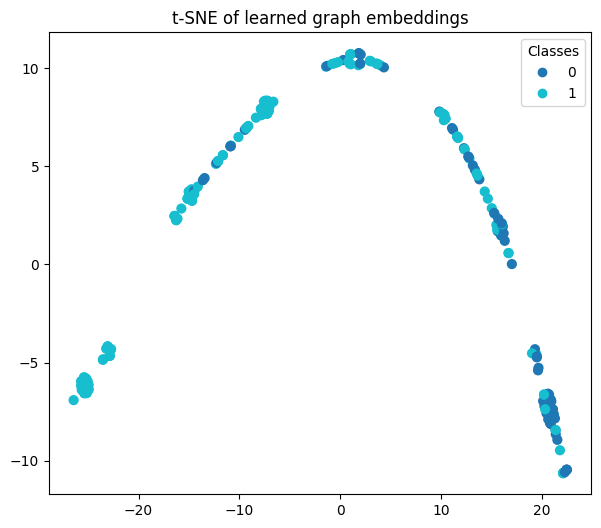

In [9]:
@torch.no_grad()
def get_graph_embeddings_and_labels():
    model.eval()
    all_embs = []
    all_labels = []
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    for batch in loader:
        batch = batch.to(device)
        emb, pred = model(batch)   
        g_emb = pyg_nn.global_mean_pool(emb, batch.batch)
        all_embs.append(g_emb.cpu())
        all_labels.append(batch.y.cpu())
    embs = torch.cat(all_embs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    return embs, labels

embs, labels = get_graph_embeddings_and_labels()
print("Embeddings shape:", embs.shape, "Labels shape:", labels.shape)

tsne = TSNE(n_components=2, random_state=42, perplexity=20)
emb2 = tsne.fit_transform(embs)

plt.figure(figsize=(7,6))
scatter = plt.scatter(emb2[:,0], emb2[:,1], c=labels, cmap='tab10', s=40)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('t-SNE of learned graph embeddings')
plt.show()